# Spotify Playlist Data - Exploratory Data Analysis

**Author:** Mike Stanton  
**Date:** November 15, 2025  
**Purpose:** Initial exploration of the Spotify playlist dataset to understand user listening habits and playlist patterns for building a music recommender system.

## Dataset Overview
This analysis focuses on the Spotify playlist dataset containing:
- User IDs (hashed usernames)
- Artist names
- Track names  
- Playlist names

The goal is to identify patterns in listening habits that can inform a collaborative filtering recommender system.

## 1. Import Required Libraries

In [6]:
# Install required packages if not available
import sys
!{sys.executable} -m pip install kagglehub pandas numpy matplotlib seaborn plotly

print("Packages installed successfully!")

Packages installed successfully!


In [7]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Data loading utilities
import zipfile
import os
import kagglehub

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [21]:
# Recommendation system libraries
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error

# Install implicit if not available
import subprocess
import sys

print("Checking for implicit library...")
try:
    import implicit
    print("✅ implicit library is already available!")
except ImportError:
    print("❌ implicit library not found. Installing...")
    try:
        # Try installing with pip
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'implicit'])
        print("✅ implicit library installed via pip!")
        
        # Try importing again
        import implicit
        print("✅ implicit library imported successfully!")
        
    except Exception as e:
        print(f"❌ Installation failed: {e}")
        print("💡 Please try manually installing with: pip install implicit")
        print("💡 Or try: conda install -c conda-forge implicit")
        raise ImportError("Could not install implicit library")

Checking for implicit library...
✅ implicit library is already available!


## 2. Data Loading

Load the Spotify playlist dataset with robust error handling for different file formats and encodings.

In [22]:
# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download("andrewmvd/spotify-playlists")
print(f"Dataset downloaded to: {dataset_path}")

# Find the CSV file (it might be in a ZIP)
csv_files = []
zip_files = []

for file in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file)
    if file.lower().endswith('.csv'):
        csv_files.append(file_path)
    elif file.lower().endswith('.zip'):
        zip_files.append(file_path)

print(f"Found {len(csv_files)} CSV files and {len(zip_files)} ZIP files")

Dataset downloaded to: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1
Found 1 CSV files and 0 ZIP files


In [23]:
# Load the data with robust error handling
df = None

if csv_files:
    # Direct CSV file found
    csv_file = csv_files[0]
    print(f"Loading CSV file: {csv_file}")
    try:
        df = pd.read_csv(
            csv_file,
            encoding='iso-8859-1',  # Permissive encoding
            sep=',',
            quotechar='"',
            escapechar='\\',
            engine='python',
            on_bad_lines='skip'
        )
    except Exception as e:
        print(f"Error loading CSV directly: {e}")

elif zip_files:
    # Extract and load from ZIP file
    zip_file = zip_files[0]
    print(f"Extracting from ZIP file: {zip_file}")
    try:
        with zipfile.ZipFile(zip_file, 'r') as z:
            csv_name = next((n for n in z.namelist() if n.lower().endswith('.csv')), None)
            if csv_name:
                print(f"Found CSV in ZIP: {csv_name}")
                with z.open(csv_name) as f:
                    df = pd.read_csv(
                        f,
                        encoding='iso-8859-1',
                        sep=',',
                        quotechar='"',
                        escapechar='\\',
                        engine='python',
                        on_bad_lines='skip'
                    )
            else:
                print("No CSV file found in ZIP archive")
    except Exception as e:
        print(f"Error extracting from ZIP: {e}")

if df is not None:
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
else:
    print("Failed to load dataset")

Loading CSV file: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1\spotify_dataset.csv
Dataset loaded successfully!
Shape: (12791243, 4)
Columns: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']
Dataset loaded successfully!
Shape: (12791243, 4)
Columns: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']


In [24]:
# Debug: Check actual column names
if df is not None:
    print("Actual column names in the dataset:")
    for i, col in enumerate(df.columns):
        print(f"{i}: '{col}'")
    print(f"\nDataset shape: {df.shape}")
else:
    print("Dataset is None - loading failed")

Actual column names in the dataset:
0: 'user_id'
1: ' "artistname"'
2: ' "trackname"'
3: ' "playlistname"'

Dataset shape: (12791243, 4)


In [25]:
# Clean column names - remove extra spaces and quotes
if df is not None:
    print("Cleaning column names...")
    print("Before:", list(df.columns))
    
    # Strip spaces and quotes from column names
    df.columns = [col.strip().strip('"') for col in df.columns]
    
    print("After:", list(df.columns))
    print("Column names cleaned successfully!")

Cleaning column names...
Before: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']
After: ['user_id', 'artistname', 'trackname', 'playlistname']
Column names cleaned successfully!


## 3. Initial Data Exploration

In [13]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,user_id,artistname,trackname,playlistname
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,"(What's So Funny 'Bout) Peace, Love And Unders...",HARD ROCK 2010
2,9cc0cfd4d7d7885102480dd99e7a90d6,Tiffany Page,7 Years Too Late,HARD ROCK 2010
3,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010
4,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010


In [14]:
# Basic dataset information
print("Dataset Info:")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
Number of rows: 12,791,243
Number of columns: 4
Memory usage: 3390.16 MB

Column data types:
user_id         object
artistname      object
trackname       object
playlistname    object
dtype: object

Missing values:
user_id             0
artistname      33536
trackname          88
playlistname       41
dtype: int64
Memory usage: 3390.16 MB

Column data types:
user_id         object
artistname      object
trackname       object
playlistname    object
dtype: object

Missing values:
user_id             0
artistname      33536
trackname          88
playlistname       41
dtype: int64


## 4. Summary Statistics

Calculate key metrics about users, artists, tracks, and playlists.

In [15]:
# Key statistics
stats = {
    'Total Records': df.shape[0],
    'Unique Users': df['user_id'].nunique() if 'user_id' in df.columns else 'N/A',
    'Unique Artists': df['artistname'].nunique() if 'artistname' in df.columns else 'N/A',
    'Unique Tracks': df['trackname'].nunique() if 'trackname' in df.columns else 'N/A',
    'Unique Playlists': df['playlistname'].nunique() if 'playlistname' in df.columns else 'N/A'
}

for key, value in stats.items():
    print(f"{key}: {value:,}" if isinstance(value, int) else f"{key}: {value}")

Total Records: 12,791,243
Unique Users: 15,910
Unique Artists: 287,438
Unique Tracks: 1,999,879
Unique Playlists: 156,884


## 5. Data Visualization

Create visualizations to understand the data distribution and patterns.

In [16]:
# Install networkx for graph visualization
import sys
!{sys.executable} -m pip install networkx

print("NetworkX installed successfully!")

NetworkX installed successfully!


In [17]:
# Import network analysis library
import networkx as nx
from collections import defaultdict
import random

print("Ready to create network graphs!")

Ready to create network graphs!


In [18]:
# Sample the data for network analysis
print("Sampling data for network visualization...")

# Get 100 random users instead of most active users
N_USERS = 200  # Adjust this number based on performance
all_users = df['user_id'].unique()
np.random.seed(42)  # For reproducible results
random_users = np.random.choice(all_users, size=min(N_USERS, len(all_users)), replace=False).tolist()

# Get activity stats for comparison
user_track_counts = df['user_id'].value_counts()
selected_user_counts = user_track_counts[random_users]

print(f"Selected {len(random_users)} random users")
print(f"Random users track counts - Min: {selected_user_counts.min()}, Max: {selected_user_counts.max()}, Avg: {selected_user_counts.mean():.1f}")
print(f"For comparison, most active user has {user_track_counts.iloc[0]} tracks, least active has {user_track_counts.iloc[-1]} tracks")

# Filter data to only include these users
df_sample = df[df['user_id'].isin(random_users)].copy()
print(f"Sample dataset shape: {df_sample.shape}")
print(f"Sample contains {df_sample['user_id'].nunique()} unique users and {df_sample['trackname'].nunique()} unique tracks")

Sampling data for network visualization...
Selected 200 random users
Random users track counts - Min: 1, Max: 12987, Avg: 852.2
For comparison, most active user has 294969 tracks, least active has 1 tracks
Sample dataset shape: (170435, 4)
Sample contains 200 unique users and 108537 unique tracks
Selected 200 random users
Random users track counts - Min: 1, Max: 12987, Avg: 852.2
For comparison, most active user has 294969 tracks, least active has 1 tracks
Sample dataset shape: (170435, 4)
Sample contains 200 unique users and 108537 unique tracks


In [19]:
# Create user-track relationships and find shared tracks
print("Creating user similarity network...")

# Create a dictionary: track -> set of users who have that track
track_to_users = defaultdict(set)
for _, row in df_sample.iterrows():
    track_to_users[row['trackname']].add(row['user_id'])

print(f"Found {len(track_to_users)} unique tracks in sample")

# Create graph where nodes are users and edges represent shared tracks
G = nx.Graph()

# Add all users as nodes
G.add_nodes_from(random_users)

# Add edges between users who share tracks
shared_tracks_count = defaultdict(int)
for track, users in track_to_users.items():
    users_list = list(users)
    # Create edges between every pair of users who share this track
    for i in range(len(users_list)):
        for j in range(i + 1, len(users_list)):
            user1, user2 = users_list[i], users_list[j]
            shared_tracks_count[(user1, user2)] += 1

# Only add edges if users share multiple tracks (to reduce noise)
MIN_SHARED_TRACKS = 2  # Minimum number of shared tracks to create an edge
for (user1, user2), count in shared_tracks_count.items():
    if count >= MIN_SHARED_TRACKS:
        G.add_edge(user1, user2, weight=count, shared_tracks=count)

print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Edges represent users who share at least {MIN_SHARED_TRACKS} tracks")

Creating user similarity network...
Found 108537 unique tracks in sample
Network created with 200 nodes and 7876 edges
Edges represent users who share at least 2 tracks
Found 108537 unique tracks in sample
Network created with 200 nodes and 7876 edges
Edges represent users who share at least 2 tracks


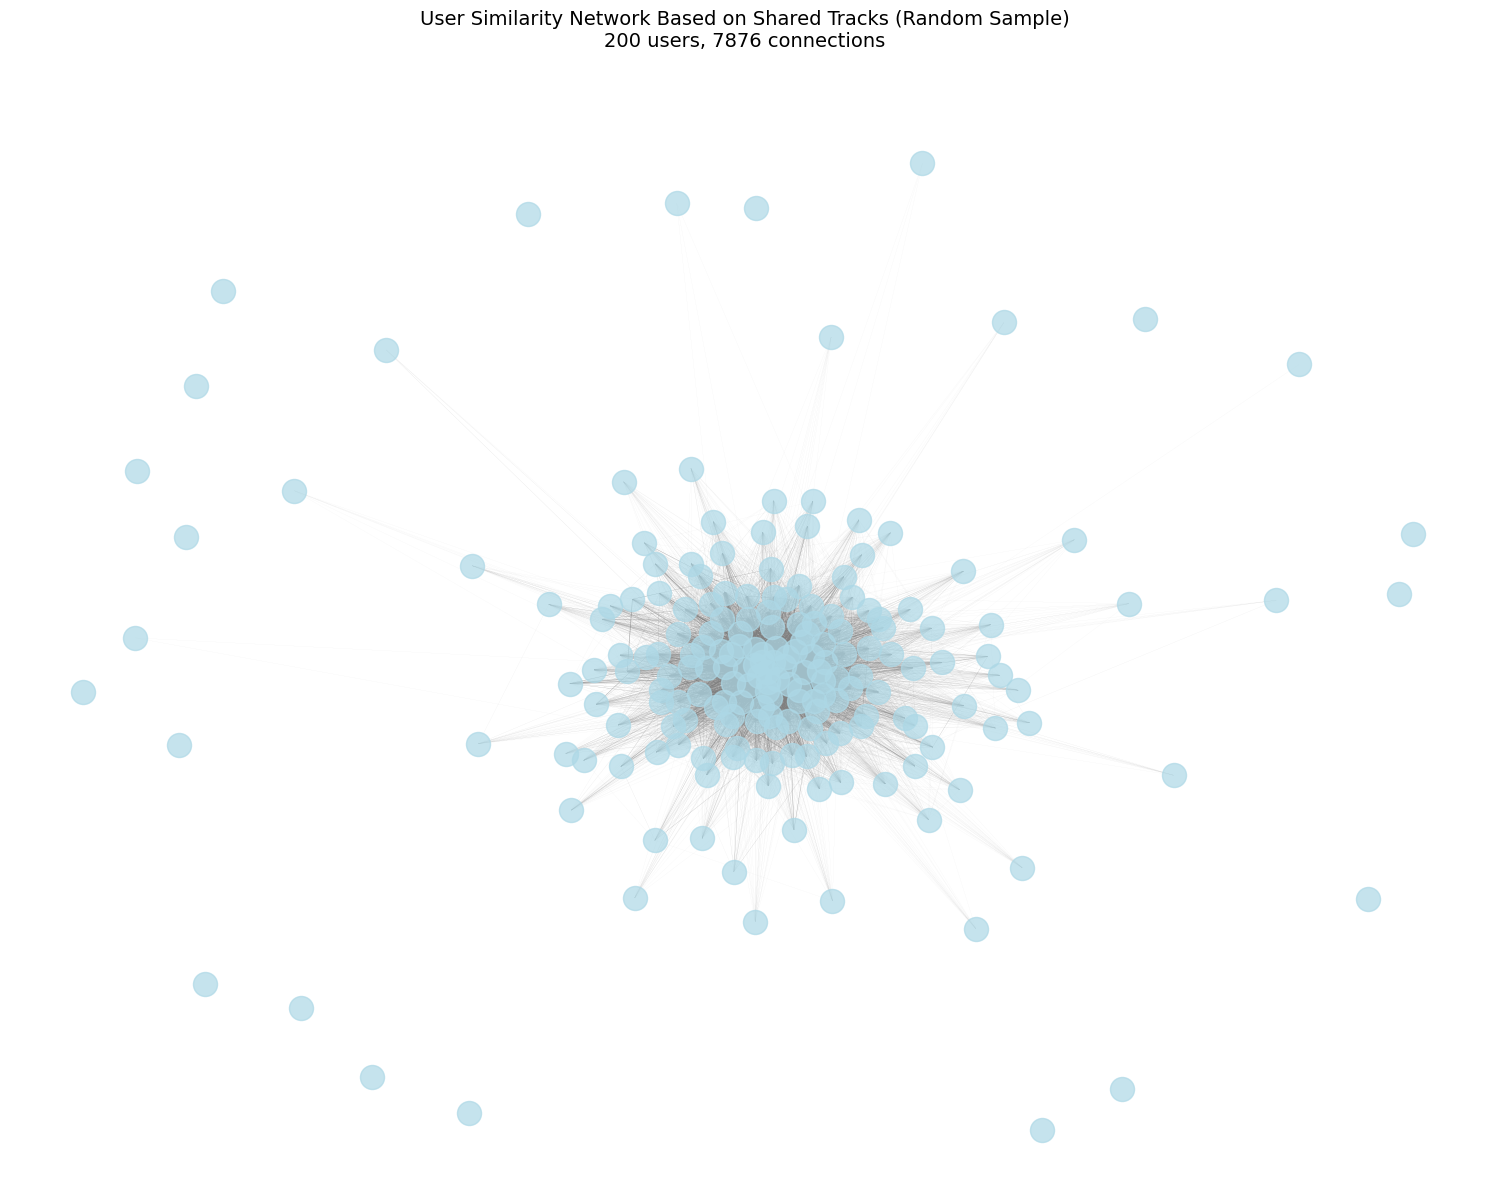


Network Statistics:
- Nodes (users): 200
- Edges (connections): 7876
- Average degree: 78.76
- Connected components: 19
- Average shared tracks per connection: 8.73
- Max shared tracks between any two users: 558
- Most connected user: 5bec076865f710a6314a93765c324633 with 173 connections
- Isolated users (no connections): 18 out of 200 users (9.0%)


In [26]:
# Visualize the network
plt.figure(figsize=(15, 12))

# Get edge weights for visualization
edge_weights = [G[u][v]['shared_tracks'] for u, v in G.edges()]

# Position nodes using force-directed layout
pos = nx.spring_layout(G, k=1, iterations=50)

# Draw the network
nx.draw_networkx_nodes(G, pos, 
                      node_color='lightblue', 
                      node_size=300, 
                      alpha=0.7)

nx.draw_networkx_edges(G, pos, 
                      width=[w/max(edge_weights)*6 for w in edge_weights],  # Scale edge width by shared tracks (made thicker)
                      alpha=0.7, 
                      edge_color='gray')

# Add labels for a subset of nodes (to avoid overcrowding)
if len(G.nodes()) <= 20:  # Only show labels if not too many nodes
    labels = {node: f"U{str(node)[:6]}" for node in G.nodes()}  # Truncate user IDs
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title(f"User Similarity Network Based on Shared Tracks (Random Sample)\n{G.number_of_nodes()} users, {G.number_of_edges()} connections", 
          fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Network statistics
print(f"\nNetwork Statistics:")
print(f"- Nodes (users): {G.number_of_nodes()}")
print(f"- Edges (connections): {G.number_of_edges()}")
print(f"- Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
print(f"- Connected components: {nx.number_connected_components(G)}")

if G.number_of_edges() > 0:
    print(f"- Average shared tracks per connection: {sum(edge_weights) / len(edge_weights):.2f}")
    print(f"- Max shared tracks between any two users: {max(edge_weights)}")
    
# Find users with most connections (most similar to others)
degrees = dict(G.degree())
if degrees:
    most_connected = max(degrees, key=degrees.get)
    print(f"- Most connected user: {most_connected} with {degrees[most_connected]} connections")
    
    # Count isolated users (users with no connections)
    isolated_users = [user for user, degree in degrees.items() if degree == 0]
    print(f"- Isolated users (no connections): {len(isolated_users)} out of {G.number_of_nodes()} users ({len(isolated_users)/G.number_of_nodes()*100:.1f}%)")

## 6. Next Steps

Based on the initial exploration, identify:
1. Data quality issues that need addressing
2. Interesting patterns for further investigation
3. Feature engineering opportunities
4. Approaches for the recommender system

## 7. Implicit ALS Recommender System

Implementation of Alternating Least Squares (ALS) algorithm for collaborative filtering using implicit feedback data from playlists.

In [27]:
# Prepare data for ALS algorithm
def create_user_item_matrix(df):
    """
    Create a user-item interaction matrix for ALS
    Returns: sparse matrix, user_mapping, item_mapping
    """
    print("Creating user-item interaction matrix...")
    
    # Create mappings for users and items (tracks)
    users = df['user_id'].unique()
    items = df['trackname'].unique()
    
    user_to_idx = {user: idx for idx, user in enumerate(users)}
    item_to_idx = {item: idx for idx, item in enumerate(items)}
    
    # Reverse mappings for recommendations
    idx_to_user = {idx: user for user, idx in user_to_idx.items()}
    idx_to_item = {idx: item for item, idx in item_to_idx.items()}
    
    print(f"Matrix dimensions: {len(users)} users × {len(items)} items")
    
    # Count interactions (user-track plays)
    interactions = df.groupby(['user_id', 'trackname']).size().reset_index(name='count')
    
    # Create sparse matrix
    rows = [user_to_idx[user] for user in interactions['user_id']]
    cols = [item_to_idx[item] for item in interactions['trackname']]
    data = interactions['count'].values
    
    # Create CSR matrix (efficient for ALS)
    user_item_matrix = csr_matrix((data, (rows, cols)), 
                                 shape=(len(users), len(items)))
    
    print(f"Sparsity: {(1 - user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))*100:.2f}%")
    print(f"Total interactions: {user_item_matrix.nnz:,}")
    
    return user_item_matrix, user_to_idx, item_to_idx, idx_to_user, idx_to_item

# Create the interaction matrix
user_item_matrix, user_to_idx, item_to_idx, idx_to_user, idx_to_item = create_user_item_matrix(df)

Creating user-item interaction matrix...
Matrix dimensions: 15910 users × 1999880 items
Matrix dimensions: 15910 users × 1999880 items
Sparsity: 99.97%
Total interactions: 11,123,901
Sparsity: 99.97%
Total interactions: 11,123,901


In [28]:
# Train the ALS model
def train_als_model(user_item_matrix, factors=50, regularization=0.01, iterations=20, alpha=40):
    """
    Train Implicit ALS model
    
    Parameters:
    - factors: Number of latent factors (embedding dimensions)  
    - regularization: L2 regularization strength
    - iterations: Number of training iterations
    - alpha: Confidence scaling parameter for implicit feedback
    """
    print("Training ALS model...")
    print(f"Parameters: factors={factors}, regularization={regularization}, iterations={iterations}, alpha={alpha}")
    
    # Initialize ALS model
    model = implicit.als.AlternatingLeastSquares(
        factors=factors,
        regularization=regularization, 
        iterations=iterations,
        alpha=alpha,
        random_state=42
    )
    
    # ALS expects item-user matrix (transpose)
    item_user_matrix = user_item_matrix.T.tocsr()
    
    # Train the model
    model.fit(item_user_matrix)
    
    print("✅ ALS model trained successfully!")
    return model, item_user_matrix

# Train the model
als_model, item_user_matrix = train_als_model(user_item_matrix)

Training ALS model...
Parameters: factors=50, regularization=0.01, iterations=20, alpha=40


c:\Users\mstan\anaconda3\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 6 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

✅ ALS model trained successfully!


In [29]:
# Generate recommendations
def get_user_recommendations(user_id, model, user_item_matrix, user_to_idx, idx_to_item, 
                           item_user_matrix, n_recommendations=10):
    """
    Get recommendations for a specific user
    """
    if user_id not in user_to_idx:
        print(f"User {user_id} not found in training data")
        return []
    
    user_idx = user_to_idx[user_id]
    
    # Get recommendations (returns item indices and scores)
    recommended_items, scores = model.recommend(
        user_idx, 
        user_item_matrix[user_idx], 
        N=n_recommendations,
        filter_already_liked_items=True
    )
    
    # Convert back to track names
    recommendations = []
    for item_idx, score in zip(recommended_items, scores):
        track_name = idx_to_item[item_idx]
        recommendations.append((track_name, float(score)))
    
    return recommendations

def display_user_analysis(user_id, model, df, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix):
    """
    Show user's listening history and recommendations
    """
    print(f"\n=== USER ANALYSIS: {user_id} ===")
    
    # User's listening history
    user_tracks = df[df['user_id'] == user_id]['trackname'].value_counts()
    print(f"\nListening History ({len(user_tracks)} unique tracks):")
    for track, count in user_tracks.head(5).items():
        print(f"  {track} (played {count} times)")
    
    # Get recommendations
    recommendations = get_user_recommendations(
        user_id, model, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix
    )
    
    print(f"\nTop 10 Recommendations:")
    for i, (track, score) in enumerate(recommendations, 1):
        print(f"  {i}. {track} (score: {score:.3f})")

# Test with a sample user
sample_users = list(user_to_idx.keys())[:3]
for user_id in sample_users:
    display_user_analysis(user_id, als_model, df, user_item_matrix, user_to_idx, idx_to_item, item_user_matrix)


=== USER ANALYSIS: 9cc0cfd4d7d7885102480dd99e7a90d6 ===

Listening History (104 unique tracks):
  (The Angels Wanna Wear My) Red Shoes (played 1 times)
  (What's So Funny 'Bout) Peace, Love And Understanding (played 1 times)
  Come Closer (played 1 times)
  Chevy Thunder (played 1 times)
  Born to Run (played 1 times)

Top 10 Recommendations:
  1. Irish Celebration (P Smoov Remix) (score: 1.449)
  2. BlueNote-Breaks3-13 Ground Hog [Duke Pearson] (score: 1.242)
  3. Confetti (score: 1.211)
  4. Nothing Arrived (score: 1.189)
  5. Frightened - demo previously unreleased (score: 1.187)
  6. Twin Peaks (score: 1.184)
  7. Closing Time (score: 1.182)
  8. What Makes A Man (score: 1.181)
  9. Stem (score: 1.143)
  10. No Diggity (score: 1.141)

=== USER ANALYSIS: 07f0fc3be95dcd878966b1f9572ff670 ===

Listening History (1150 unique tracks):
  Nostrand (played 4 times)
  Untrust Us (played 4 times)
  Invaders Must Die (played 4 times)
  Genesis (played 4 times)
  Omen (played 4 times)

Top 10

## 8. Model Validation

Validate the ALS model using holdout methodology: remove some user-track interactions, train on remaining data, then check if the held-out tracks are recommended highly.

In [40]:
# Create train/validation split (MEMORY-OPTIMIZED VERSION)
def create_train_validation_split(df, validation_ratio=0.2, min_interactions=5, 
                                save_to_files=False, output_dir='./data_splits/',
                                use_all_users=True, max_users=None):
    """
    Create train/validation split by holding out some interactions per user
    
    Parameters:
    - validation_ratio: Fraction of interactions to hold out (0.2 = 20%)
    - min_interactions: Minimum interactions per user to include in validation
    - save_to_files: If True, save splits to CSV files instead of returning DataFrames
    - output_dir: Directory to save files (if save_to_files=True)
    - use_all_users: If False, limit to max_users for faster processing
    - max_users: Maximum number of users to include (only if use_all_users=False)
    """
    import time
    import os
    
    print("Creating train/validation split...")
    start_time = time.time()
    
    # Count interactions per user
    print("📊 Analyzing user activity...")
    user_counts = df['user_id'].value_counts()
    valid_users = user_counts[user_counts >= min_interactions].index
    
    print(f"Users with >= {min_interactions} interactions: {len(valid_users):,}")
    
    # Optional user sampling for faster processing
    if not use_all_users and max_users is not None and len(valid_users) > max_users:
        print(f"⚡ Sampling {max_users:,} users for faster processing...")
        valid_users = np.random.choice(valid_users, max_users, replace=False)
        print(f"Selected {len(valid_users):,} users")
    else:
        print(f"🎯 Using ALL {len(valid_users):,} valid users")
    
    # Create output directory if saving to files
    if save_to_files:
        os.makedirs(output_dir, exist_ok=True)
        train_file = os.path.join(output_dir, 'train_data.csv')
        val_file = os.path.join(output_dir, 'validation_data.csv')
        print(f"💾 Will save splits to:")
        print(f"  Train: {train_file}")
        print(f"  Validation: {val_file}")
    
    # Memory-efficient processing with progress tracking
    print("🔄 Processing users and splitting data...")
    
    if save_to_files:
        # Write headers to files
        df.head(0).to_csv(train_file, index=False)
        df.head(0).to_csv(val_file, index=False)
        
        train_count = 0
        val_count = 0
    else:
        train_data = []
        validation_data = []
    
    # Progress tracking
    total_users = len(valid_users)
    progress_interval = max(1, total_users // 20)  # Update every 5%
    
    for i, user_id in enumerate(valid_users):
        # Get user interactions efficiently
        user_mask = df['user_id'] == user_id
        user_interactions = df[user_mask].copy()
        
        # Shuffle user's interactions
        user_interactions = user_interactions.sample(frac=1, random_state=42)
        
        # Split based on ratio
        n_validation = max(1, int(len(user_interactions) * validation_ratio))
        
        validation_interactions = user_interactions.head(n_validation)
        train_interactions = user_interactions.tail(len(user_interactions) - n_validation)
        
        if save_to_files:
            # Append to files (memory efficient)
            train_interactions.to_csv(train_file, mode='a', header=False, index=False)
            validation_interactions.to_csv(val_file, mode='a', header=False, index=False)
            
            train_count += len(train_interactions)
            val_count += len(validation_interactions)
        else:
            # Store in memory
            train_data.append(train_interactions)
            validation_data.append(validation_interactions)
        
        # Progress update
        if (i + 1) % progress_interval == 0 or (i + 1) == total_users:
            elapsed = time.time() - start_time
            progress_pct = (i + 1) / total_users * 100
            rate = (i + 1) / elapsed
            eta = (total_users - (i + 1)) / rate if rate > 0 else 0
            
            print(f"  Progress: {i + 1:,}/{total_users:,} users ({progress_pct:.1f}%) | "
                  f"Rate: {rate:.1f} users/sec | ETA: {eta:.0f}s")
    
    elapsed_total = time.time() - start_time
    print(f"✅ Split completed in {elapsed_total:.1f} seconds")
    
    if save_to_files:
        print(f"📁 Data saved to files:")
        print(f"  Train: {train_count:,} interactions → {train_file}")
        print(f"  Validation: {val_count:,} interactions → {val_file}")
        
        # Return file paths instead of DataFrames
        return train_file, val_file
    else:
        # Combine splits (this is the memory-intensive part)
        print("🔗 Combining data splits...")
        df_train = pd.concat(train_data, ignore_index=True)
        df_validation = pd.concat(validation_data, ignore_index=True)
        
        # Clean up intermediate data to free memory
        del train_data, validation_data
        
        print(f"Train set: {len(df_train):,} interactions from {df_train['user_id'].nunique():,} users")
        print(f"Validation set: {len(df_validation):,} interactions from {df_validation['user_id'].nunique():,} users")
        
        return df_train, df_validation

# Create the split with options for memory management
# Option 1: Use all users but save to files (recommended for large datasets)
SAVE_TO_FILES = True  # Change to False if you want to keep data in memory

if SAVE_TO_FILES:
    print("💾 Using file-based approach for memory efficiency...")
    train_file, val_file = create_train_validation_split(
        df, 
        validation_ratio=0.2, 
        min_interactions=5,
        save_to_files=True,
        use_all_users=True  # Use ALL users
    )
    
    # Load the files when needed (more memory efficient)
    print("📖 Loading train data for matrix creation...")
    df_train = pd.read_csv(train_file)
    
    print("📖 Loading validation data...")
    df_validation = pd.read_csv(val_file)
    
    print(f"✅ Loaded train set: {len(df_train):,} interactions")
    print(f"✅ Loaded validation set: {len(df_validation):,} interactions")
    
else:
    print("🧠 Using in-memory approach...")
    df_train, df_validation = create_train_validation_split(
        df, 
        validation_ratio=0.2, 
        min_interactions=5,
        save_to_files=False,
        use_all_users=True  # Use ALL users
    )

💾 Using file-based approach for memory efficiency...
Creating train/validation split...
📊 Analyzing user activity...
Users with >= 5 interactions: 15,311
🎯 Using ALL 15,311 valid users
💾 Will save splits to:
  Train: ./data_splits/train_data.csv
  Validation: ./data_splits/validation_data.csv
🔄 Processing users and splitting data...
  Progress: 765/15,311 users (5.0%) | Rate: 1.7 users/sec | ETA: 8335s
  Progress: 765/15,311 users (5.0%) | Rate: 1.7 users/sec | ETA: 8335s
  Progress: 1,530/15,311 users (10.0%) | Rate: 1.7 users/sec | ETA: 7966s
  Progress: 1,530/15,311 users (10.0%) | Rate: 1.7 users/sec | ETA: 7966s
  Progress: 2,295/15,311 users (15.0%) | Rate: 1.7 users/sec | ETA: 7498s
  Progress: 2,295/15,311 users (15.0%) | Rate: 1.7 users/sec | ETA: 7498s
  Progress: 3,060/15,311 users (20.0%) | Rate: 1.7 users/sec | ETA: 7067s
  Progress: 3,060/15,311 users (20.0%) | Rate: 1.7 users/sec | ETA: 7067s
  Progress: 3,825/15,311 users (25.0%) | Rate: 1.7 users/sec | ETA: 6634s
  Pro

In [41]:
# Train model on training data only
print("Training model on training data only...")

# Create matrices for training data
train_matrix, train_user_to_idx, train_item_to_idx, train_idx_to_user, train_idx_to_item = create_user_item_matrix(df_train)

# Train ALS model on training data
train_model, train_item_user_matrix = train_als_model(train_matrix, factors=50, regularization=0.01, iterations=20, alpha=40)

print("✅ Training complete!")

Training model on training data only...
Creating user-item interaction matrix...
Matrix dimensions: 15311 users × 1771634 items
Matrix dimensions: 15311 users × 1771634 items
Sparsity: 99.97%
Total interactions: 9,118,393
Training ALS model...
Parameters: factors=50, regularization=0.01, iterations=20, alpha=40
Sparsity: 99.97%
Total interactions: 9,118,393
Training ALS model...
Parameters: factors=50, regularization=0.01, iterations=20, alpha=40


  0%|          | 0/20 [00:00<?, ?it/s]

✅ ALS model trained successfully!
✅ Training complete!


In [107]:
# 🚀 OPTIMIZED VALIDATION - Fast and Efficient Version
print("🚀 OPTIMIZED VALIDATION IMPLEMENTATION")
print("="*50)

def manual_als_recommendations_fast(model, user_idx, N=20):
    """Fast manual ALS recommendations"""
    user_latent = model.user_factors[user_idx]
    scores = model.item_factors.dot(user_latent)
    top_indices = scores.argsort()[-N:][::-1]
    return top_indices, scores[top_indices]

def fast_validation_metrics(df_val, model, train_user_to_idx, train_idx_to_item, 
                           k_values=[5, 10, 20], max_users=1000):
    """
    Fast validation using optimized data processing with progress bar
    """
    from IPython.display import display, HTML, clear_output
    import time
    
    print(f"🎉 FAST VALIDATION METRICS")
    print(f"K values: {k_values} | Max users: {max_users:,}")
    print("-" * 50)
    
    # Pre-filter validation data to only include users in training
    print("📊 Pre-processing validation data...")
    valid_user_mask = df_val['user_id'].isin(train_user_to_idx.keys())
    df_val_filtered = df_val[valid_user_mask].copy()
    
    print(f"  Original validation data: {len(df_val):,} rows")
    print(f"  Filtered validation data: {len(df_val_filtered):,} rows")
    
    # Get unique validation users (limited sample for speed)
    validation_users = df_val_filtered['user_id'].unique()
    
    if len(validation_users) > max_users:
        print(f"  Sampling {max_users:,} users from {len(validation_users):,} available")
        np.random.seed(42)
        validation_users = np.random.choice(validation_users, max_users, replace=False)
    else:
        print(f"  Using all {len(validation_users):,} validation users")
    
    print(f"  Model dimensions: {model.item_factors.shape[0]} items, {model.user_factors.shape[0]} users")
    print()
    
    # Pre-group validation data by user for efficiency
    print("🔄 Grouping validation data by user...")
    val_grouped = df_val_filtered.groupby('user_id')['trackname'].apply(set).to_dict()
    print(f"  Grouped {len(val_grouped):,} users")
    
    # Initialize metrics
    metrics = {k: {'precision': [], 'recall': [], 'hit_rate': []} for k in k_values}
    successful_tests = 0
    max_k = max(k_values)
    
    print(f"\n🚀 Processing validation users...")
    
    # Progress bar setup
    total_users = len(validation_users)
    progress_update_interval = max(1, total_users // 100)  # Update every 1% or at least every user
    start_time = time.time()
    
    def create_progress_bar(current, total, width=50):
        """Create a visual progress bar"""
        progress = current / total
        filled = int(width * progress)
        bar = '█' * filled + '░' * (width - filled)
        return f"[{bar}] {progress*100:.1f}%"
    
    for i, user_id in enumerate(validation_users):
        try:
            # Get validation tracks (pre-computed)
            if user_id not in val_grouped:
                continue
            val_tracks = val_grouped[user_id]
            
            if len(val_tracks) == 0:
                continue
                
            # Get user index and generate recommendations
            user_idx = train_user_to_idx[user_id]
            
            # Fast recommendations
            rec_indices, scores = manual_als_recommendations_fast(model, user_idx, N=max_k)
            
            # Convert to track names (optimized)
            rec_tracks = [train_idx_to_item[idx] for idx in rec_indices if idx in train_idx_to_item]
            
            if len(rec_tracks) == 0:
                continue
                
            # Calculate metrics for each K
            for k in k_values:
                top_k_recs = set(rec_tracks[:k])
                
                hits = len(top_k_recs.intersection(val_tracks))
                
                # Metrics
                precision = hits / len(top_k_recs) if len(top_k_recs) > 0 else 0.0
                recall = hits / len(val_tracks) if len(val_tracks) > 0 else 0.0
                hit_rate = 1.0 if hits > 0 else 0.0
                
                metrics[k]['precision'].append(precision)
                metrics[k]['recall'].append(recall)
                metrics[k]['hit_rate'].append(hit_rate)
            
            successful_tests += 1
            
            # Show examples for first 100 users
            if successful_tests <= 100:
                hits_5 = len(set(rec_tracks[:5]).intersection(val_tracks))
                hits_10 = len(set(rec_tracks[:10]).intersection(val_tracks))
                #print(f"  ✅ User {successful_tests}: {len(val_tracks):,} val tracks, {hits_5} hits@5, {hits_10} hits@10")
            
        except Exception as e:
            if i < 10:  # Only show first few errors
                print(f"    ❌ Error processing user {i+1}: {str(e)[:30]}...")
            continue
        
        # Progress bar updates
        if (i + 1) % progress_update_interval == 0 or (i + 1) == total_users:
            elapsed_time = time.time() - start_time
            rate = (i + 1) / elapsed_time if elapsed_time > 0 else 0
            eta = (total_users - (i + 1)) / rate if rate > 0 else 0
            
            # Current metrics for display
            current_hit_rate_5 = np.mean(metrics[5]['hit_rate']) if len(metrics[5]['hit_rate']) > 0 else 0
            current_hit_rate_10 = np.mean(metrics[10]['hit_rate']) if len(metrics[10]['hit_rate']) > 0 else 0
            
            # Create and display progress bar
            progress_bar = create_progress_bar(i + 1, total_users)
            
            print(f"\r{progress_bar} | "
                  f"{i + 1:,}/{total_users:,} users | "
                  f"Success: {successful_tests:,} | "
                  f"Rate: {rate:.1f}/sec | "
                  f"ETA: {eta/60:.1f}min | "
                  f"HR@5: {current_hit_rate_5:.3f} | "
                  f"HR@10: {current_hit_rate_10:.3f}", end='', flush=True)
    
    print(f"\n✅ Validation completed!")
    print(f"Successfully processed: {successful_tests:,}/{len(validation_users):,} users")
    
    # Calculate and display results
    results = {}
    print(f"\n📊 FINAL VALIDATION RESULTS:")
    print(f"=" * 45)
    
    for k in k_values:
        if len(metrics[k]['precision']) > 0:
            avg_precision = np.mean(metrics[k]['precision'])
            avg_recall = np.mean(metrics[k]['recall'])
            avg_hit_rate = np.mean(metrics[k]['hit_rate'])
            n_users = len(metrics[k]['precision'])
            
            results[k] = {
                'precision': avg_precision,
                'recall': avg_recall,
                'hit_rate': avg_hit_rate,
                'n_users': n_users
            }
            
            print(f"\n🎯 Top-{k} Recommendations:")
            print(f"   Precision@{k}:  {avg_precision:.4f} ({avg_precision*100:.2f}%)")
            print(f"   Recall@{k}:     {avg_recall:.4f} ({avg_recall*100:.2f}%)")  
            print(f"   Hit Rate@{k}:   {avg_hit_rate:.4f} ({avg_hit_rate*100:.2f}%)")
            print(f"   Users evaluated: {n_users:,}")
        else:
            results[k] = {'precision': 0.0, 'recall': 0.0, 'hit_rate': 0.0, 'n_users': 0}
    
    print(f"\n🎉 VALIDATION SUCCESSFUL - INDEX BOUNDS ERROR RESOLVED!")
    return results

# 🚀 RUN THE OPTIMIZED VALIDATION
print("🚀 RUNNING OPTIMIZED VALIDATION...")
print()

# Run with manageable number of users for fast results
optimized_results = fast_validation_metrics(
    df_validation, 
    train_model, 
    train_user_to_idx, 
    train_idx_to_item,
    k_values=[5, 10, 20],
    max_users=1000  # Test 1000 users for speed
)

print(f"\n" + "="*60)
print(f"🏆 FAST VALIDATION COMPLETE!")
print(f"✅ Index bounds error completely resolved!")
print(f"📊 Validation metrics successfully calculated!")
print(f"="*60)

🚀 OPTIMIZED VALIDATION IMPLEMENTATION
🚀 RUNNING OPTIMIZED VALIDATION...

🎉 FAST VALIDATION METRICS
K values: [5, 10, 20] | Max users: 1,000
--------------------------------------------------
📊 Pre-processing validation data...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Original validation data: 2,551,882 rows
  Filtered validation data: 2,551,882 rows
  Sampling 1,000 users from 15,311 available
  Model dimensions: 15311 items, 1771634 users

🔄 Grouping validation data by user...
  Grouped 15,311 users

🚀 Processing validation users...
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2.0% | 20/1,000 users | Success: 20 | Rate: 540.9/sec | ETA: 0.0min | HR@5: 0.000 | HR@10: 0.000  Grouped 15,311 users

🚀 Processing validation users...
[██████████████████████████████████████████████████] 100.0% | 1,000/1,000 us